In [137]:
import csv
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn import linear_model

## Rezolvarea problemei (pt datele v1) cu cod propriu (fara biblioteci specializate – e.g. sklearn, numpy, skit, opencv, etc) cu un parametru

#### Pasul 1 - plot pt distributia datelor & plot pt “verificarea” liniaritatii (daca legatura intre y si x e una liniara)

In [138]:
def loadData(fileName, inputVariableName, outputVariableName):
    data = []
    dataNames = []

    with open(fileName) as csv_file: # deschidem csv-ul
        csv_reader = csv.reader(csv_file, delimiter=',') # citim datele din csv
        line_count = 0 # suntem pe prima linie
        for row in csv_reader:
            if line_count == 0: # daca suntem pe prima linie, atunci inseamna ca suntem pe headerul tabelului
                dataNames = row # salvam numele coloanelor
            else: # daca nu suntem pe prima linie, atunci salvam datele de pe randul curent
                data.append(row)
            line_count += 1
        selectedVariable = dataNames.index(inputVariableName) # cautam pe ce index se afla coloana cu numele inputVariableName
        inputs = [float(data[i][selectedVariable]) for i in range(len(data))] # salvam valorile din coloana respectiva
        selectedOutput = dataNames.index(outputVariableName) # cautam pe ce index se afla coloana cu numele outputVariableName
        outputs = [float(data[i][selectedOutput]) for i in range(len(data))] # salvam valorile din coloana respectiva

    return inputs, outputs

In [139]:
crtDir = os.getcwd() # luam calea catre folderul curent
filePath = os.path.join(crtDir, 'data', 'v2_world-happiness-report-2017.csv') # construim calea catre csv

inputs, outputs = loadData(filePath, 'Family', 'Happiness.Score') # incarcam datele din csv
# inputs = normalizeData(inputs) # normalizam datele de intrare

print('input data: ', inputs[:5])
print('output data: ', outputs[:5])

input data:  [1.53352356, 1.551121593, 1.610574007, 1.516911745, 1.540246725]
output data:  [7.537000179, 7.521999836, 7.504000187, 7.493999958, 7.468999863]


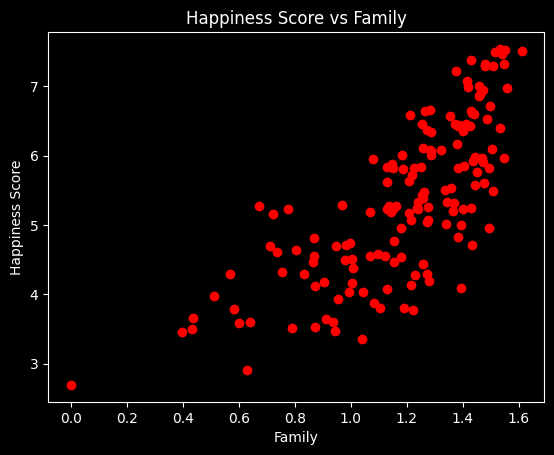

In [140]:
plt.plot(inputs, outputs, 'ro') # afisam datele sub forma de puncte rosii
plt.xlabel('Family')
plt.ylabel('Happiness Score')
plt.title('Happiness Score vs Family')
plt.show()

O clasificam intr-o problema de regresie liniara, deoarece se pare ca exista o legatura liniara intre cele doua variabile (se poate observa din plotul de mai sus).

<img src="images/regression.png" width="200">

#### Pasul 2 - impartire date pe train si validation

In [141]:
import random
indexes = list(range(len(inputs)))
random.shuffle(indexes)

split = int(0.8 * len(inputs))

trainSample = indexes[:split]
validationSample = indexes[split:]

trainInputs = [inputs[i] for i in trainSample] # datele de intrare pentru train
trainOutputs = [outputs[i] for i in trainSample] # datele de iesire pentru train

validationInputs = [inputs[i] for i in validationSample] # datele de intrare pentru validation
validationOutputs = [outputs[i] for i in validationSample] # datele de iesire pentru validation

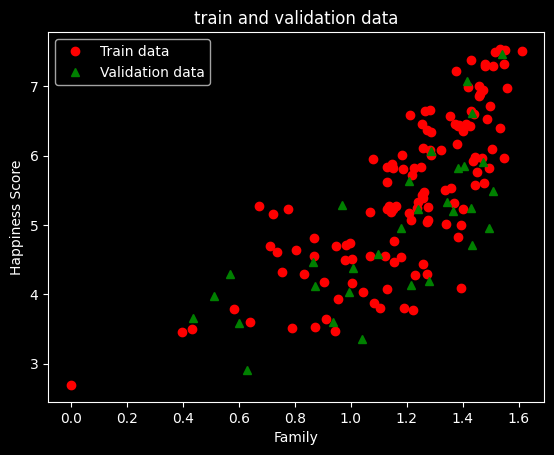

In [142]:
plt.plot(trainInputs, trainOutputs, 'ro', label='Train data') # afisam datele de train sub forma de puncte rosii
plt.plot(validationInputs, validationOutputs, 'g^', label='Validation data') # afisam datele de validation sub forma de triunghiuri verzi
plt.title('train and validation data')
plt.xlabel('Family')
plt.ylabel('Happiness Score')
plt.legend()
plt.show()

#### Pasul 3 - invatare model (fara tool generic si fara tool de least square)

**Metoda celor mai mici patrate**

Presupunem cazul unei regresii univariate (un exemplu are un singur atribut, deci $f(x,w) = w_0 + w_1 * x_1$.
Se doreste identificarea valorilor optime pentru coeficientii **w**=$[w_0, w_1]$ stiindu-se un set de $n$ exemple de antrenament de forma $(x^i, y^i)$, cu $i = 1, 2, ..., n$, $x^i = (x^i_1)$.

Se defineste o functie de cost: $cost(x) = \sum_{i=1}^{n}(y^i_{computed} - y^i)^2$. Se identifica punctul de minim al acestei functii, care duce la valorile optime pt **w**.

$$w_1 = \frac{n \sum_{i=1}^{n}(x^i * y^i) -\sum_{i=1}^{n}x^i * \sum_{i=1}^{n}y^i}{n \sum_{i=1}^{n}(x^i)^2 - (\sum_{i=1}^{n}x^i)^2} $$

$$w_0 = \frac{\sum_{i=1}^{n}y^i - w_1 \sum_{i=1}^{n}x^i}{n}$$

Pentru cazul unei regresii multi-variate ($m$ atribute): $f(x,w) = w_0 + w_1 * x_1 + w_2 * x_2 + ... w_m * x_m$) si un set de date cu $n$ exemple:

$\boldsymbol{w} = (X^{T}X)^{-1}X^{T}{Y}$,
unde $X = (x^i_{j})$, $Y = (y^i)$, $i = 1, 2, ..., n$, $j = 1, 2, ..., m$.

In [143]:
def computeWeights(inputs, outputs):
    sumInputs = sum(inputs)
    sumOutputs = sum(outputs)
    sumInputs2 = sum(i * i for i in inputs)
    sumInputsOutputs = sum(i * j for (i,j) in zip(inputs, outputs))
    w1 = (len(inputs) * sumInputsOutputs - sumInputs * sumOutputs) / (len(inputs) * sumInputs2 - sumInputs * sumInputs)
    w0 = (sumOutputs - w1 * sumInputs) / len(inputs)
    return w0, w1

In [144]:
w0, w1 = computeWeights(trainInputs, trainOutputs)
print('The model learnt: f(x) = ', w0, ' + ', w1, ' * x')

The model learnt: f(x) =  1.7831870630427864  +  3.062767182485427  * x


#### Pasul 4 - plot rezultate (model invatat, predictii)

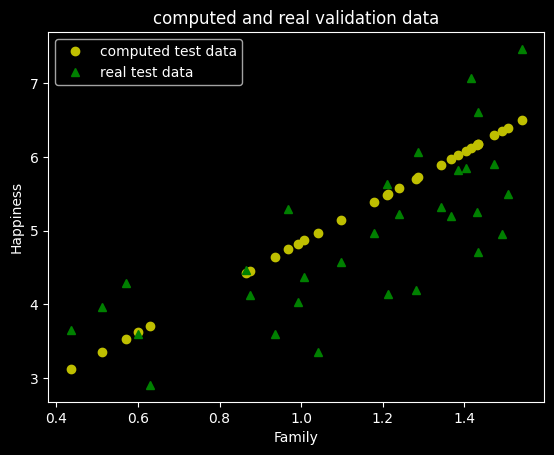

In [145]:
# Plotam linia pe care modelul a invatat-o peste datele reale
# Preparam niste data, unde input-urile sunt random, iar output-urile sunt computate de model
# Plotam mai intai peste datele de training
noOfPoints = 1000 # cate puncte vrem sa generam pentru a trasa linia
xref = []
val = min(trainInputs) # incepem de la cel mai mic input
step = (max(trainInputs) - min(trainInputs)) / noOfPoints # distanta dintre puncte
for i in range(1, noOfPoints): # construim xref, care va contine noOfPoints numere intre min(trainInputs) si max(trainInputs)
    xref.append(val)
    val += step
yref = [w0 + w1 * x for x in xref]

plt.plot(trainInputs, trainOutputs, 'ro', label = 'training data')
plt.plot(xref, yref, 'b-', label = 'learnt model')
plt.title('computed and real training data')
plt.xlabel('Family')
plt.ylabel('Happiness')
plt.legend()
plt.show()

# Plotam dupa peste datele de validare
computedValidationOutputs = ([w0 + w1 * feature for feature in validationInputs])
plt.plot(validationInputs, computedValidationOutputs, 'yo', label = 'computed test data')
plt.plot(validationInputs, validationOutputs, 'g^', label = 'real test data')
plt.title('computed and real validation data')
plt.xlabel('Family')
plt.ylabel('Happiness')
plt.legend()
plt.show()

#### Pasul 5 - calcul metrici de performanta (eroarea)

### Evaluarea performantei regresorului (a se vedea materialele din laboratorul 6)

- the absolute difference  (this is $L_1$ distance):
$$Error = \frac{1}{n} \times \sum_{i=1}^{n} |y^i - y^i_{computed}| = Mean Absolute Error (MAE)$$
- the square difference (this is the $L_2$ distance):
$$Error = \sqrt{\frac{1}{n} \times \sum_{i=1}^{n} (y^i - y^i_{computed}) ^ 2} = Root Mean Square Error (RMSE)$$

In [146]:
import math

mean_abs_error = 0.0
for t1, t2 in zip(validationOutputs, computedValidationOutputs):
    mean_abs_error += abs(t1 - t2)
mean_abs_error /= len(validationOutputs)
print('mean absolute error:', mean_abs_error)

mean_squared_error = 0.0
for t1, t2 in zip(validationOutputs, computedValidationOutputs):
    mean_squared_error += ((t1 - t2) ** 2)
mean_squared_error /= len(validationOutputs)
mean_squared_error = math.sqrt(mean_squared_error)
print('mean squared error:  ', mean_squared_error)

mean absolute error: 0.6964976015777811
mean squared error:   0.8205254572881763
